## This notebook is meant to be a module to read and filter and prepare the enformer and AF tables of mohan
- last column: AF=...;AC=... (remove AF= and split to two column)
- add a header
- make it a good pandas df to merge with the header
- see "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/MPRAlm/scripts/reading_enformer_tsv.py" as well

In [2]:
import yaml
import os
import pandas as pd


# config 
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/config/config.yaml"
config_path = "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/04_MPRAlm/config/config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [3]:
## functions for this type of files

def load_df_add_columns(file_path):
    """Add column names and return dataframe"""
    enformer_af_df = pd.read_csv(file_path, sep="\t", header=None)
    enformer_af_df.columns = ["CHROM", "POS", "ID", "REF", "ALT", "enformer_value", "max_enformer_column",  "QUAL", "FILTER", "INFO"]
    return enformer_af_df

def seperate_columns_by_pattern(df, column_with_pattern, pattern, new_column_names, drop_original_column=True):
    """Seperates columns by pattern and adds new column names"""
    extracted_df = df[column_with_pattern].str.extract(pattern)
    extracted_df.columns = new_column_names
    if drop_original_column:
        df = df.drop(column_with_pattern, axis=1)
    df = pd.concat([df, extracted_df], axis=1)
    return df

def get_AF_AC_from_INFO_column(enformer_df):
    """Adds AF and AC columns instead of INFO column"""
    df = seperate_columns_by_pattern(enformer_df, "INFO", r'AF=(?P<AF>[\d.e-]+);AC=(?P<AC>\d+)', ["AF", "AC"], drop_original_column=True)
    return df

def get_rows(df):
    """Get a specific number of rows"""
    pass

def get_higher_lower_subset(enformer_df, variant_sum=5000, higher_fraction = 0.7, lower_fraction = 0.15, column="enformer_value"):
    """Get higher 70% and lower 15% of the enformer df sorted by column such that it sums up to 5000"""
    # sort the df 
    enformer_sorted = enformer_df.sort_values(by=column, ascending=False)
    
    # get top 0.7 * 5000 rows
    top_rows = int(variant_sum * higher_fraction)
    bottom_rows = int(variant_sum * lower_fraction)
    enformer_high = enformer_sorted.iloc[:top_rows]
    
    enformer_low = enformer_sorted.iloc[len(enformer_sorted)-bottom_rows:]
    #! TODO: debugging enformer high: only 2500 rows in current table (at least 5000 are expected)
    print("expected number of enformer high: ", top_rows)
    print("current number of enformer high: ", len(enformer_high))
    print("expected number of enformer low: ", bottom_rows)
    print("current number of enformer low: ", len(enformer_low))
    # check if len(enformer_low) equals bottom_rows
    if len(enformer_high) != top_rows:
        print("Top rows does not work")
    else:
        print("Top rows work")
    if len(enformer_low) == bottom_rows:
        print("bottom rows work")
    else: 
        print("bottom rows do not work")
    return enformer_high, enformer_low
    

In [4]:
_verbose = config["verbose"]
enformer_prediction_value = "enformer_value"
variant_sum=5000 
higher_fraction = 0.7
lower_fraction = 0.15
# read as tab separated file 
for name in config["condition_names"]:
    print(f"----{name}------")
    file_name = name + "." + ".".join(config["default_name"].split(".")[1:]) # pathing the file name from the config
    enformer_af_path = os.path.join(config["enformer_results_dir"], file_name)
    print(enformer_af_path)
    # load table and add columns
    enformer_af_df = load_df_add_columns(enformer_af_path)  
    # print(enformer_af_df.head())
    ## change info column AF=...;AC=... into two columns (AF, AC)
    enformer_af_ac_df = get_AF_AC_from_INFO_column(enformer_af_df)
    # sort by ac (to test)
    enformer_sorted = enformer_af_ac_df.sort_values(by=enformer_prediction_value, ascending=False)
    
    # take num * fraction first / last elements
    enformer_high, enformer_low = get_higher_lower_subset(enformer_df=enformer_af_ac_df, column=enformer_prediction_value)
    #! TODO: enformer_high set is broken (intitial table has a length of 2500 (expected 5000)) check if you downloaded the correct one
    # write enformer_low
    low_number = ""
    high_number = ""
    if _verbose:
        # expected number _ real number
        low_number = "_" + str(int(variant_sum * lower_fraction)) + "_" + str(len(enformer_low))
        high_number = "_" + str(int(variant_sum * higher_fraction)) + "_" + str(len(enformer_high))
    output_low = ".".join(file_name.split(".")[:-1]) + f"{low_number}_low.tsv"
    output_high = ".".join(file_name.split(".")[:-1]) + f"{high_number}_high.tsv"
    enformer_low.to_csv(os.path.join(config["output_dir"], output_low), sep="\t", header=True, index=False)
    enformer_high.to_csv(os.path.join(config["output_dir"], output_high), sep="\t", header=True, index=False)


----cardiac------
/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/cardiac.ultra-rare_variants_0402.tsv
expected number of enformer high:  3500
current number of enformer high:  3500
expected number of enformer low:  750
current number of enformer low:  750
Top rows work
bottom rows work
----cava------
/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/cava.ultra-rare_variants_0402.tsv
expected number of enformer high:  3500
current number of enformer high:  3500
expected number of enformer low:  750
current number of enformer low:  750
Top rows work
bottom rows work
----neuro------
/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/neuro.ultra-rare_variants_0402.tsv
expected number of enformer high:  3500
current number of enformer high:  3500
expected number of enformer low:  750
current number of enformer low:  750
Top rows work
bottom rows work
----random------
/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/rando

## Match the enformer low (working) with the significant results of MPRAlm

In [5]:
mpra_results = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/MPRAlm/results/NGN2_output/mpralm/toptable_2701_all_NGN2.feather"
mpra_df = pd.read_feather(mpra_results)

enformer_low_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/high_low_tables/cardiac.ultra-rare_variants_750_750_low.tsv"
enformer_low = pd.read_csv(enformer_low_path, sep="\t")
print(enformer_low.head())

   CHROM        POS                                                 ID REF  \
0   chr5  180608335  FLT4|ENSG00000037280.16|EH38E3684204|5-1806083...   C   
1  chr16   54080804  FTO|ENSG00000140718.21|EH38E1816677|16-5408080...   G   
2   chr1   15680797  PLEKHM2|ENSG00000116786.13|EH38E1321744|1-1568...   G   
3   chr2  105447631  FHL2|ENSG00000115641.19|EH38E2021840|2-1054476...   T   
4   chr1  201421798  TNNT2|ENSG00000118194.21|EH38E2857804|1-201421...   A   

  ALT  enformer_value       max_enformer_column  QUAL FILTER        AF   AC  
0   A       384.77628           425_DNASE:Caki2     1   PASS  0.000013    2  
1   A       384.43860           234_DNASE:HepG2     1   PASS  0.000039    6  
2   A       384.17420            625_DNASE:K562     1   PASS  0.000013    2  
3   G       383.85290            636_DNASE:PC-9     1   PASS  0.000020    3  
4   T       383.79480  282_DNASE:gastrocnemius      1   PASS  0.003134  473  


In [6]:
p_sig_toptable = mpra_df[mpra_df["adj.P.Val"] < 0.05]
p_sig_toptable.head()
#! TODO: table from chrom pos ref alt to header and id for each sequence
p_sig_toptable.merge(enformer)

NameError: name 'enformer' is not defined

## Proof of concept 70% high 15% low

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# load all files in directory having 0402.tsv in the name
def read_files_with_ending(file_path, ending):
    """Read files with a specific ending in a directory"""
    file_list = []
    for file in os.listdir(file_path):
        if file.endswith(ending):
            file_list.append(os.path.join(file_path, file))
    return file_list
file_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results"
ending="0402.tsv"
print(read_files_with_ending(file_path, ending))

['/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/random.ultra-rare_variants_0402.tsv', '/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/cardiac.singleton_variants_0402.tsv', '/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/cardiac.ultra-rare_variants_0402.tsv', '/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/neuro.ultra-rare_variants_0402.tsv', '/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/neuro.singleton_variants_0402.tsv', '/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/cava.singleton_variants_0402.tsv', '/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/cava.ultra-rare_variants_0402.tsv']


In [9]:
# read the ultra-rare variants
cardiac_combined_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/cardiac.ultra-rare_variants_0402.tsv"
cardiac_combined_df = pd.read_csv(cardiac_combined_path, sep="\t")
cardiac_combined_df


,#CHROM,POS,ID,REF,ALT,DNase_max,INDEX_max,QUAL,FILTER,INFO
0,chr7,151844596,PRKAG2|ENSG00000106617.15|EH38E2601933|7-15184...,A,G,3825.041500,392_DNASE:CD14-positive,1,PASS,AF=1.31399e-05;AC=2
1,chr9,107505071,KLF4|ENSG00000136826.15|EH38E2715497|9-1075050...,T,G,3807.484400,392_DNASE:CD14-positive,1,PASS,AF=0.000453428;AC=69
2,chr7,151806383,PRKAG2|ENSG00000106617.15|EH38E3809265|7-15180...,A,G,3154.359900,392_DNASE:CD14-positive,1,PASS,AF=5.91195e-05;AC=9
3,chr19,55119303,TNNI3|ENSG00000129991.13|EH38E3317178|19-55119...,C,T,2987.777800,392_DNASE:CD14-positive,1,PASS,AF=1.97278e-05;AC=3
4,chr15,67093652,SMAD3|ENSG00000166949.17|EH38E3141522|15-67093...,C,G,2872.473900,392_DNASE:CD14-positive,1,PASS,AF=1.9707e-05;AC=3
...,...,...,...,...,...,...,...,...,...,...
4995,chrX,137566358,ZIC3|ENSG00000156925.12|EH38E3946556|X-1375663...,G,A,-0.605268,32_DNASE:iPS-NIHi7 fema,1,PASS,AF=5.34497e-05;AC=6
4996,chr19,18932700,GDF1|ENSG00000130283.9|EH38E3296795|19-1893270...,G,A,-0.611493,135_DNASE:fibroblast of,1,PASS,AF=0.000645;AC=98
4997,chr19,46697216,FKRP|ENSG00000181027.11|EH38E1958533|19-466972...,G,A,-0.839309,355_DNASE:superior tempo,1,PASS,AF=1.97608e-05;AC=3
4998,chr19,55118532,TNNI3|ENSG00000129991.13|EH38E1964550|19-55118...,G,A,-0.999476,24_DNASE:HeLa-S3 treate,1,PASS,AF=7.88716e-05;AC=12


In [18]:
merged_combined_path = "/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/80K_MPRA/enformer_results/enformer_class/merged_enformer_class.tsv"
merged_enformer_df = pd.read_csv(merged_combined_path, sep='\t')
merged_enformer_df
merged_enformer_df["gene_set"].value_counts() 
# cava       10000
# cardiac    10000
# neuro      10000
# random      2500 (2500 singleton missing)

gene_set
cava       10000
cardiac    10000
neuro      10000
random      2500
Name: count, dtype: int64

In [12]:
def plot_dnas_max_distribution(df, name, output_dir):
    """Plot the distribution of the DNase_max column in the dataframe"""
    df.index
    fig, axs = plt.subplots(figsize=(12, 4))
    df["DNase_max"].plot(ax=axs, title=f"DNase Max distribution for {name}")
    axs.set_xlabel("Variant")
    axs.get_xaxis().set_ticks([])
    axs.set_ylabel("DNase Max")
    fig.savefig(os.path.join(output_dir, f"{name}_DNase_max_distribution.png"))
    plt.show()

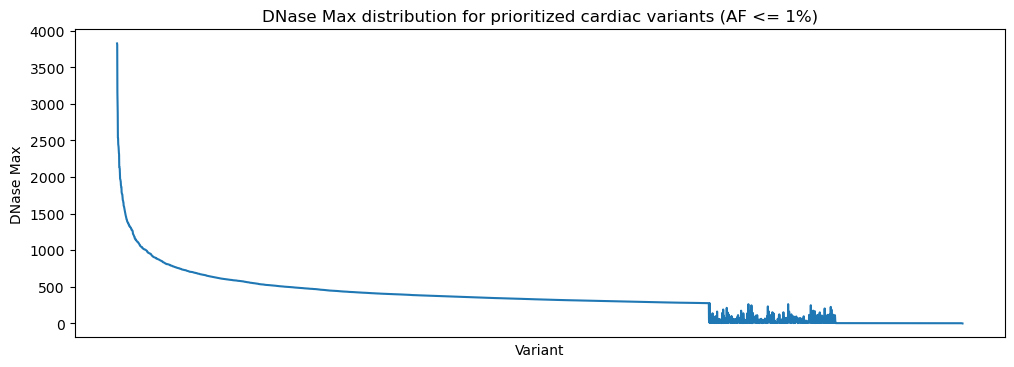

In [16]:
# plot the DNase_max distribution:
output_dir = '/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/04_MPRAlm/results/DNase_max_distribution'
plot_dnas_max_distribution(cardiac_combined_df, "prioritized cardiac variants (AF <= 1%)", output_dir)

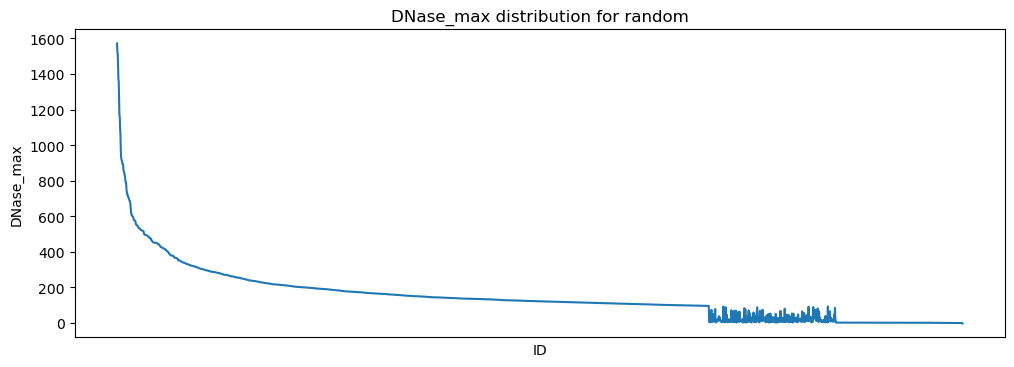

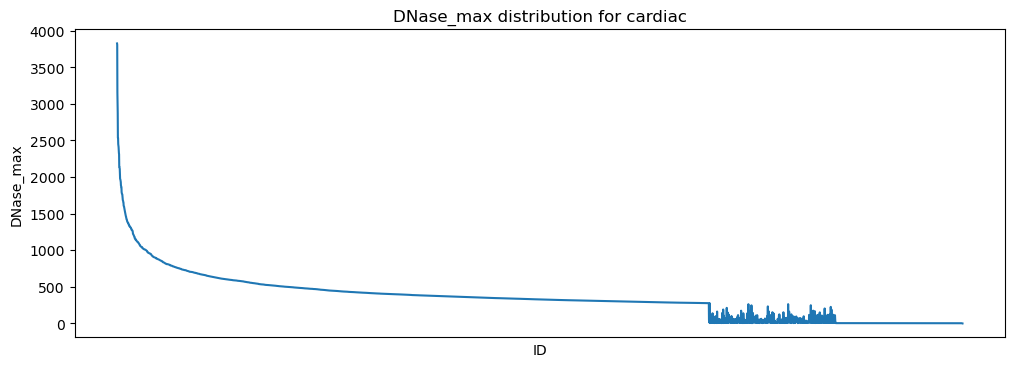

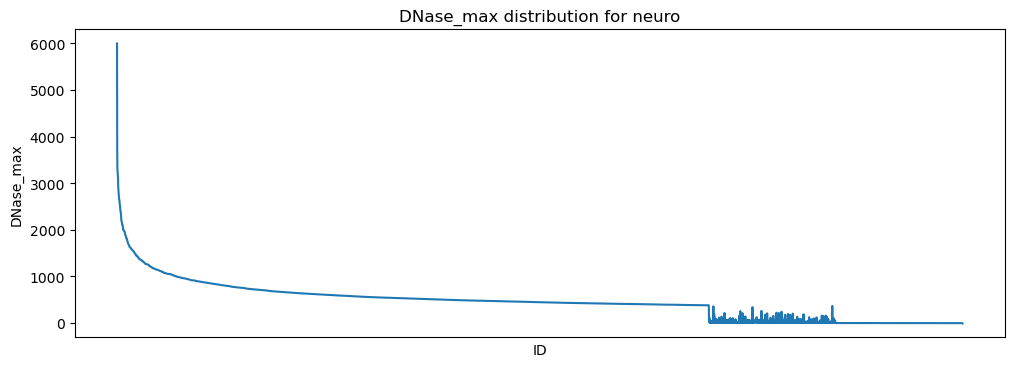

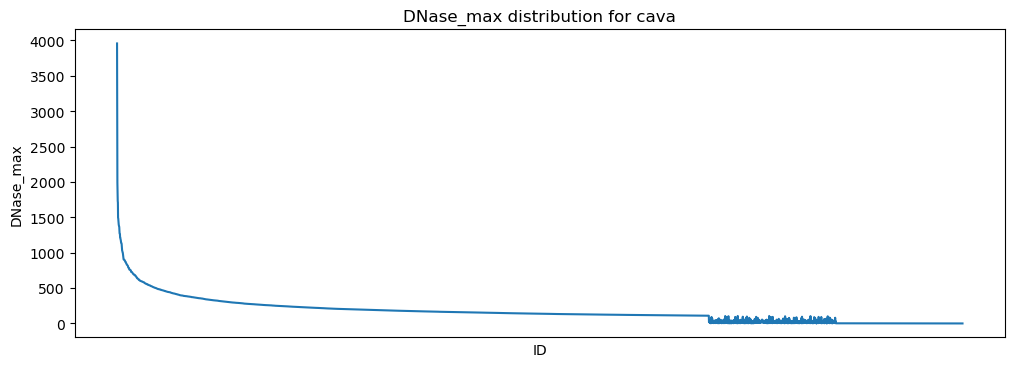

In [42]:
file_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results"
ending="0402.tsv"
output_dir = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/DNase_max_distribution"
file_list = read_files_with_ending(file_path, ending)
for file in file_list:
    # read as df 
    df = pd.read_csv(file, sep="\t")
    # name = split(/)[-1] + split(.)[0]
    name = file.split("/")[-1].split(".")[0]
    # plot the DNase_max distribution
    plot_dnas_max_distribution(df, name, output_dir)

In [ ]:
# same for the singleton variants

## Include the high low information of enformer

In [42]:
file_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results"
ending="0402.tsv"
outpath = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/enformer_class"
file_list = read_files_with_ending(file_path, ending)
file_list
for file in file_list:
    print(file)
    # read as df 
    df = pd.read_csv(file, sep="\t")
    # sort it by DNase_max
    df_sorted = df.sort_values(by="DNase_max", ascending=False)
    # name = split(/)[-1] + split(.)[0]
    name = file.split("/")[-1].split(".")[0]
    variant_type = file.split("/")[-1].split(".")[1].split("_")[0]
    df_sorted["gene_set"] = name
    df_sorted["variant_type"] = variant_type
    # add new column: enformer_class: enformer_high, enformer_low, random
    # set first 0.7 * 5000 rows enformer_high and 0.15 * 5000 rows enformer_low (tail) rest is random
    variant_sum = 5000
    if name == "random":
        variant_sum = 2500
    
    high_number = int(0.7 * variant_sum)
    low_number = int(0.15 * variant_sum)
    df_sorted["enformer_class"] = "random"
    df_sorted.iloc[:high_number, df_sorted.columns.get_loc("enformer_class")] = "enformer_high"
    df_sorted.iloc[-low_number:, df_sorted.columns.get_loc("enformer_class")] = "enformer_low"
    
    # write to a new file
    file_name = ".".join(file.split("/")[-1].split(".")[:-1]).split("_")[0] + "_enformer_class.tsv"
    df_sorted.to_csv(os.path.join(outpath, file_name), sep="\t", header=True, index=False)
    

/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/random.ultra-rare_variants_0402.tsv
/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/cardiac.singleton_variants_0402.tsv
/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/cardiac.ultra-rare_variants_0402.tsv
/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/neuro.ultra-rare_variants_0402.tsv
/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/neuro.singleton_variants_0402.tsv
/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/cava.singleton_variants_0402.tsv
/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/cava.ultra-rare_variants_0402.tsv


## Add the enformer information to the annotation of the significant results of MPRAlm

In [58]:
toptable_mpralm_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/MPRAlm/results/NGN2_output/mpralm/toptable_mpralm.csv"
toptable_mpralm_df = pd.read_csv(toptable_mpralm_path, index_col=0)
# split variant_id at : and take the second part 
toptable_mpralm_df["var_id"] = toptable_mpralm_df["variant_id"].str.split("|").str[-1]
toptable_mpralm_df

# concat enformer_class tables (tables with the information about enformer_class, gene_set and variant_type)
file_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/enformer_class"
ending = "_class.tsv"
file_list = read_files_with_ending(file_path, ending)
# empty dataframe for concatinating
enformer_class_df = pd.DataFrame()
for file in file_list:
    enformer_class = pd.read_csv(file, sep="\t")
    enformer_class["var_id"] = enformer_class["ID"].str.split("|").str[-1]
    enformer_class = enformer_class[["var_id", "DNase_max", "enformer_class", "gene_set", "variant_type"]]
    enformer_class_df = pd.concat([enformer_class_df, enformer_class])
print("Expect: 35000, but since random.singleton is missing: 32500 is fine ", len(enformer_class_df)) 

toptable_mpralm_merged = toptable_mpralm_df.merge(enformer_class_df, on="var_id", how="left")
print(toptable_mpralm_merged.head())
print(len(toptable_mpralm_merged))
# how many without NA in enformer_class # 8964 without NA
print(toptable_mpralm_merged["enformer_class"].isna().sum()/len(toptable_mpralm_merged)) 
# value count
toptable_mpralm_merged["enformer_class"].value_counts()
# for each variant_id put the enformer_class in the toptable_mpralm_df

Expect: 35000, but since random.singleton is missing: 32500 is fine  32500
      logFC   AveExpr          t       P.Value     adj.P.Val           B  \
0  1.405459  1.779925  16.343686  5.966671e-60  1.259087e-55  123.851984   
1  1.461423  0.673326  14.537740  7.982489e-48  8.422324e-44   95.885456   
2  1.528669  0.951499  11.926336  9.168757e-33  6.449304e-29   61.312948   
3  1.026733  1.106780  10.681717  1.289127e-26  6.800792e-23   48.979467   
4 -1.197234  0.772053 -10.386340  2.963358e-25  1.250656e-21   45.452959   

                                          variant_id        AF  \
0  cardiac_neuro_cava_random:TRIO|ENSG00000038382...  0.000007   
1  cardiac_neuro_cava_random:TRIO|ENSG00000038382...  0.016828   
2  cardiac_neuro_cava_random:ANKZF1|ENSG000001635...  0.000007   
3  cardiac_neuro_cava_random:SLC1A2|ENSG000001104...  0.221018   
4  cardiac_neuro_cava_random:DISC1|ENSG0000016294...  0.668747   

            var_id  DNase_max enformer_class gene_set variant_type  
0 

enformer_class
enformer_high    6089
random           1612
enformer_low     1263
Name: count, dtype: int64

In [53]:
toptable_mpralm_merged["enformer_class"].dropna()

0        enformer_high
5        enformer_high
6        enformer_high
7        enformer_high
8        enformer_high
             ...      
21237    enformer_high
21239    enformer_high
21240    enformer_high
21243    enformer_high
21244           random
Name: enformer_class, Length: 8964, dtype: object

In [62]:
p_sig = toptable_mpralm_merged[toptable_mpralm_merged["adj.P.Val"] < 0.05]
p_sig
# number of na values in enformer_class
# p_sig["enformer_class"].isna().sum() # 67 / 150

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,AF,var_id,DNase_max,enformer_class,gene_set,variant_type
0,1.405459,1.779925,16.343686,5.966671e-60,1.259087e-55,123.851984,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,0.000007,5-14408059-A-G,496.1264,enformer_high,neuro,singleton
1,1.461423,0.673326,14.537740,7.982489e-48,8.422324e-44,95.885456,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,0.016828,5-14259916-C-T,NaN,NaN,NaN,NaN
2,1.528669,0.951499,11.926336,9.168757e-33,6.449304e-29,61.312948,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,0.000007,2-219267001-T-C,NaN,NaN,NaN,NaN
3,1.026733,1.106780,10.681717,1.289127e-26,6.800792e-23,48.979467,cardiac_neuro_cava_random:SLC1A2|ENSG000001104...,0.221018,11-35289966-C-T,NaN,NaN,NaN,NaN
4,-1.197234,0.772053,-10.386340,2.963358e-25,1.250656e-21,45.452959,cardiac_neuro_cava_random:DISC1|ENSG0000016294...,0.668747,1-231734633-A-G,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,-0.395139,0.320175,-3.600648,3.176065e-04,4.590502e-02,0.012774,cardiac_neuro_cava_random:NRXN3|ENSG0000002164...,0.000033,14-78255335-C-A,859.8599,enformer_high,neuro,ultra-rare
149,0.316635,0.166213,3.622316,2.921477e-04,4.498021e-02,-0.040976,cardiac_neuro_cava_random:TNRC6B|ENSG000001003...,0.028869,22-40190230-C-A,NaN,NaN,NaN,NaN
151,-0.388725,-0.010023,-3.577704,3.468190e-04,4.911794e-02,-0.071196,cardiac_neuro_cava_random:MTOR|ENSG00000198793...,0.017322,1-11197219-G-A,NaN,NaN,NaN,NaN
152,-0.282888,-0.219675,-3.633131,2.801685e-04,4.412026e-02,-0.082209,cardiac_neuro_cava_random:TNRC6B|ENSG000001003...,0.000007,22-40289571-G-A,1334.9043,enformer_high,neuro,singleton


## Check the number of labels in the positive and negative class

In [68]:
def enformer_info_print(df, description):
    print(f"Number of {description} effects: ", len(df))
    print(df.enformer_class.value_counts())
    print("Number of NA values: ", df["enformer_class"].isna().sum())

In [70]:
pos_effect = p_sig[p_sig["logFC"] > 0]
neg_effect = p_sig[p_sig["logFC"] < 0]
# print("number positive effects: ", len(pos_effect)) # 83
# print(pos_effect.enformer_class.value_counts())
# print("Number of na values in positive effects: ", pos_effect["enformer_class"].isna().sum()) # 28 )
enformer_info_print(pos_effect, "positive")
enformer_info_print(neg_effect, "negative")

# Number of positive effects:  83
# enformer_class
# enformer_high    42
# random           12
# enformer_low      1
# Name: count, dtype: int64
# Number of NA values:  28
# Number of negative effects:  69
# enformer_class
# enformer_high    24
# random            5
# enformer_low      1
# Name: count, dtype: int64
# Number of NA values:  39

Number of positive effects:  83
enformer_class
enformer_high    42
random           12
enformer_low      1
Name: count, dtype: int64
Number of NA values:  28
Number of negative effects:  69
enformer_class
enformer_high    24
random            5
enformer_low      1
Name: count, dtype: int64
Number of NA values:  39


In [72]:
not_matchable_variants = toptable_mpralm_merged[toptable_mpralm_merged["enformer_class"].isna()]
not_matching_output = "/home/kisa/coding/80K_MPRA/80K-Analysis/04_MPRAlm/enformer_results/mot_matching_variants"
not_matchable_variants.to_csv(os.path.join(not_matching_output, "not_matchable_variants.tsv"), index=False, sep="\t")